# Stock Price Exploration

This notebook explores historical stock price data, visualizes trends, engineers time-series features, and prepares the dataset for next-day stock forecasting.

The notebook matches the updated pipeline logic used in the main project:

- target = **next-day return**
- predictions are later converted back into **next-day closing price estimates**
- feature engineering includes lag, rolling, momentum, volatility, and volume-based signals


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


## Set Project Root

If this notebook is opened from the `notebooks/` folder, move one level up so project-relative paths work correctly.


In [2]:
if Path.cwd().name == 'notebooks':
    os.chdir('..')

print('Current working directory:', Path.cwd())


Current working directory: d:\Python_Projects\stock_price_predictor_scaffold\stock_price_predictor


## Load Dataset

This notebook uses one generated raw dataset from the pipeline.


In [3]:
file_path = Path('data/raw/AAPL_stock_data.csv')
df = pd.read_csv(file_path, skiprows=[1])
df.head()


,Date,Close,High,Low,Open,Volume
0,2018-01-02,40.304173,40.313533,39.602254,39.812832,102223600
1,2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2,2018-01-04,40.484325,40.587274,40.262052,40.369677,89738400
3,2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000
4,2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200


## Basic Data Inspection


In [4]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())


Shape: (2084, 6)

Columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2084 entries, 0 to 2083
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2084 non-null   object 
 1   Close   2084 non-null   float64
 2   High    2084 non-null   float64
 3   Low     2084 non-null   float64
 4   Open    2084 non-null   float64
 5   Volume  2084 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 97.8+ KB


In [6]:
df.isna().sum()


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Prepare Columns

Convert the date column and make sure price columns are numeric.


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()


,Date,Close,High,Low,Open,Volume
0,2018-01-02,40.304173,40.313533,39.602254,39.812832,102223600
1,2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2,2018-01-04,40.484325,40.587274,40.262052,40.369677,89738400
3,2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000
4,2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200


## Closing Price Trend


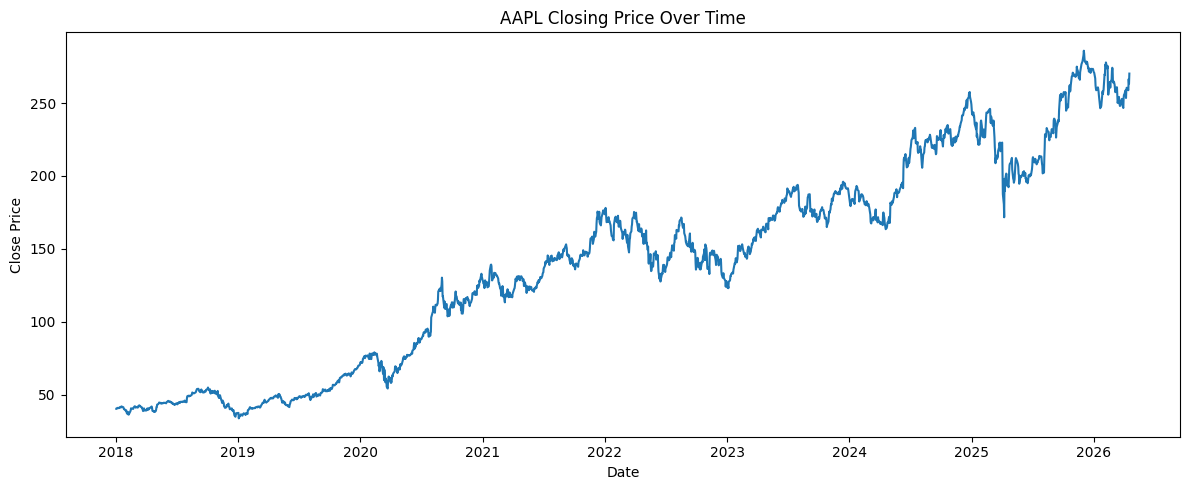

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'])
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.tight_layout()
plt.show()


## Feature Engineering

Create the same types of features used in the training pipeline.


In [9]:
# Daily return
df['daily_return'] = df['Close'].pct_change()

# Price lag features
df['close_lag_1'] = df['Close'].shift(1)
df['close_lag_2'] = df['Close'].shift(2)
df['close_lag_3'] = df['Close'].shift(3)

# Return lag features
df['return_lag_1'] = df['daily_return'].shift(1)
df['return_lag_2'] = df['daily_return'].shift(2)
df['return_lag_3'] = df['daily_return'].shift(3)

# Rolling statistics
df['rolling_mean_5'] = df['Close'].rolling(window=5).mean()
df['rolling_std_5'] = df['Close'].rolling(window=5).std()
df['rolling_mean_10'] = df['Close'].rolling(window=10).mean()
df['rolling_std_10'] = df['Close'].rolling(window=10).std()

# Relative price vs trend
df['price_vs_rolling_mean_5'] = df['Close'] / df['rolling_mean_5'] - 1.0
df['price_vs_rolling_mean_10'] = df['Close'] / df['rolling_mean_10'] - 1.0

# Momentum features
df['momentum_5'] = df['Close'] / df['Close'].shift(5) - 1.0
df['momentum_10'] = df['Close'] / df['Close'].shift(10) - 1.0

# Intraday / volatility signals
df['high_low_range'] = (df['High'] - df['Low']) / df['Close']
df['open_close_diff'] = (df['Close'] - df['Open']) / df['Open']
df['volume_change'] = df['Volume'].pct_change()

# Target variable: next-day return
df['target'] = df['Close'].shift(-1) / df['Close'] - 1.0

# Keep next-day close for interpretation
df['next_close'] = df['Close'].shift(-1)

df.head(10)


,Date,Close,High,Low,Open,Volume,daily_return,close_lag_1,close_lag_2,close_lag_3,...,rolling_std_10,price_vs_rolling_mean_5,price_vs_rolling_mean_10,momentum_5,momentum_10,high_low_range,open_close_diff,volume_change,target,next_close
0,2018-01-02,40.304173,40.313533,39.602254,39.812832,102223600,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.017648,0.012341,NaN,-0.000174,40.297153
1,2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600,-0.000174,40.304173,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.015038,-0.001739,0.155033,0.004645,40.484325
2,2018-01-04,40.484325,40.587274,40.262052,40.369677,89738400,0.004645,40.297153,40.304173,NaN,...,NaN,NaN,NaN,NaN,NaN,0.008033,0.002840,-0.239966,0.011385,40.945259
3,2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000,0.011385,40.484325,40.297153,40.304173,...,NaN,NaN,NaN,NaN,NaN,0.013257,0.008994,0.054621,-0.003714,40.793175
4,2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200,-0.003714,40.945259,40.484325,40.297153,...,NaN,0.005629,NaN,NaN,NaN,0.009636,0.000000,-0.130693,-0.000115,40.788494
5,2018-01-09,40.788494,40.959293,40.573239,40.839968,86336000,-0.000115,40.793175,40.945259,40.484325,...,NaN,0.003119,NaN,0.012017,NaN,0.009465,-0.001260,0.049407,-0.000229,40.779144
6,2018-01-10,40.779144,40.781486,40.477321,40.514757,95839600,-0.000229,40.788494,40.793175,40.945259,...,NaN,0.000517,NaN,0.011961,NaN,0.007459,0.006526,0.110077,0.005680,41.010765
7,2018-01-11,41.010765,41.059901,40.825928,40.849323,74670800,0.005680,40.779144,40.788494,40.793175,...,NaN,0.003607,NaN,0.013004,NaN,0.005705,0.003952,-0.220877,0.010327,41.434265
8,2018-01-12,41.434265,41.497439,41.097344,41.221349,101672400,0.010327,41.010765,40.779144,40.788494,...,NaN,0.011550,NaN,0.011943,NaN,0.009656,0.005165,0.361609,-0.005082,41.223679
9,2018-01-16,41.223679,41.972391,41.211979,41.623770,118263600,-0.005082,41.434265,41.010765,40.779144,...,0.372069,0.004298,0.010235,0.010553,NaN,0.018446,-0.009612,0.163183,0.016516,41.904545


## Missing Values After Feature Engineering

Missing values appear naturally because lag, rolling, and shifted target calculations require neighboring rows.


In [10]:
df.isna().sum()


Date                         0
Close                        0
High                         0
Low                          0
Open                         0
Volume                       0
daily_return                 1
close_lag_1                  1
close_lag_2                  2
close_lag_3                  3
return_lag_1                 2
return_lag_2                 3
return_lag_3                 4
rolling_mean_5               4
rolling_std_5                4
rolling_mean_10              9
rolling_std_10               9
price_vs_rolling_mean_5      4
price_vs_rolling_mean_10     9
momentum_5                   5
momentum_10                 10
high_low_range               0
open_close_diff              0
volume_change                1
target                       1
next_close                   1
dtype: int64

## Daily Return Visualization


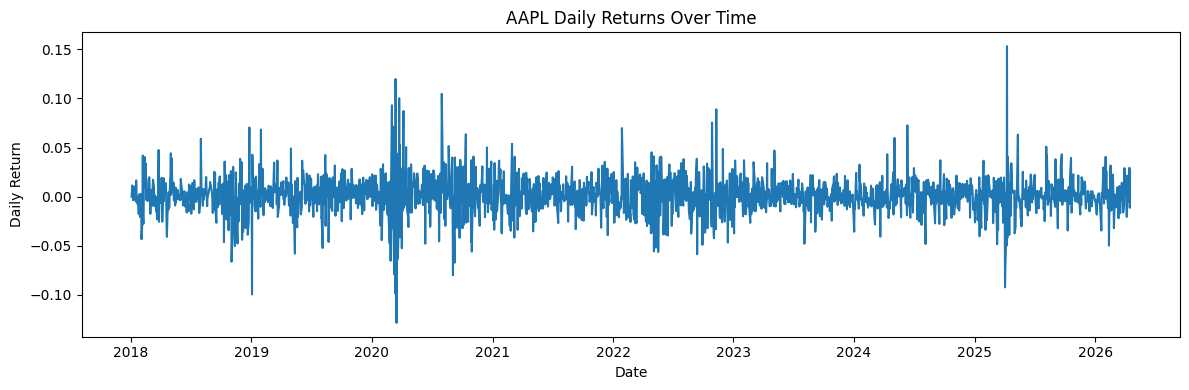

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['daily_return'])
plt.title('AAPL Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.show()


## Clean Modeling Dataset

Drop rows with missing values before model training.


In [12]:
df_model = df.dropna().copy()
print('Clean dataset shape:', df_model.shape)
df_model.head()


Clean dataset shape: (2073, 26)


,Date,Close,High,Low,Open,Volume,daily_return,close_lag_1,close_lag_2,close_lag_3,...,rolling_std_10,price_vs_rolling_mean_5,price_vs_rolling_mean_10,momentum_5,momentum_10,high_low_range,open_close_diff,volume_change,target,next_close
10,2018-01-17,41.904545,41.939639,40.961634,41.214322,137547200,0.016516,41.223679,41.434265,41.010765,...,0.464833,0.015364,0.022908,0.027362,0.039707,0.023339,0.016747,0.163056,0.000894,41.941994
11,2018-01-18,41.941994,42.138534,41.705682,41.967731,124773600,0.000894,41.904545,41.223679,41.434265,...,0.492050,0.010576,0.019728,0.028516,0.040818,0.010320,-0.000613,-0.092867,-0.004463,41.754807
12,2018-01-19,41.754807,42.016855,41.509134,41.789901,129700400,-0.004463,41.941994,41.904545,41.223679,...,0.470185,0.002472,0.012051,0.018143,0.031382,0.012160,-0.000840,0.039486,-0.008181,41.413204
13,2018-01-22,41.413204,41.595703,41.319616,41.483397,108434400,-0.008181,41.754807,41.941994,41.904545,...,0.458792,-0.005629,0.002634,-0.000508,0.011429,0.006667,-0.001692,-0.163962,0.000226,41.422565
14,2018-01-23,41.422565,41.984103,41.371095,41.483401,130756400,0.000226,41.413204,41.754807,41.941994,...,0.422611,-0.006353,0.001335,0.004825,0.015429,0.014799,-0.001466,0.205857,-0.015928,40.762772


## Correlation Analysis

Inspect the relationship between selected engineered features and the target variable.


In [13]:
corr_cols = [
    'target',
    'daily_return',
    'return_lag_1',
    'return_lag_2',
    'return_lag_3',
    'momentum_5',
    'momentum_10',
    'price_vs_rolling_mean_5',
    'price_vs_rolling_mean_10',
    'high_low_range',
    'open_close_diff',
    'volume_change',
]

df_model[corr_cols].corr()


,target,daily_return,return_lag_1,return_lag_2,return_lag_3,momentum_5,momentum_10,price_vs_rolling_mean_5,price_vs_rolling_mean_10,high_low_range,open_close_diff,volume_change
target,1.000000,-0.068620,0.016096,-0.027445,-0.019538,-0.035875,-0.032967,-0.055415,-0.046624,0.003413,-0.048754,0.004693
daily_return,-0.068620,1.000000,-0.068365,0.015382,-0.027279,0.424580,0.313287,0.722812,0.521218,-0.074517,0.770074,-0.050656
return_lag_1,0.016096,-0.068365,1.000000,-0.068019,0.015306,0.404169,0.266456,0.498189,0.432777,-0.130534,-0.069073,-0.011965
return_lag_2,-0.027445,0.015382,-0.068019,1.000000,-0.067903,0.426056,0.300743,0.344115,0.387725,-0.137369,-0.005275,-0.025441
return_lag_3,-0.019538,-0.027279,0.015306,-0.067903,1.000000,0.407598,0.273499,0.156525,0.321475,-0.078449,-0.022926,0.058813
momentum_5,-0.035875,0.424580,0.404169,0.426056,0.407598,1.000000,0.688404,0.801711,0.918353,-0.266113,0.314880,-0.032030
momentum_10,-0.032967,0.313287,0.266456,0.300743,0.273499,0.688404,1.000000,0.567098,0.833448,-0.290371,0.213039,-0.016201
price_vs_rolling_mean_5,-0.055415,0.722812,0.498189,0.344115,0.156525,0.801711,0.567098,1.000000,0.861723,-0.216895,0.537836,-0.042559
price_vs_rolling_mean_10,-0.046624,0.521218,0.432777,0.387725,0.321475,0.918353,0.833448,0.861723,1.000000,-0.297928,0.383224,-0.030877
high_low_range,0.003413,-0.074517,-0.130534,-0.137369,-0.078449,-0.266113,-0.290371,-0.216895,-0.297928,1.000000,-0.015723,0.260395


## Feature / Target Preview

Prepare the same type of model matrix used by the pipeline.


In [14]:
excluded_columns = {'Date', 'target', 'next_close'}
feature_columns = [col for col in df_model.columns if col not in excluded_columns]

X = df_model[feature_columns]
y = df_model['target']

print('Feature shape:', X.shape)
print('Target shape:', y.shape)
X.head()


Feature shape: (2073, 23)
Target shape: (2073,)


,Close,High,Low,Open,Volume,daily_return,close_lag_1,close_lag_2,close_lag_3,return_lag_1,...,rolling_std_5,rolling_mean_10,rolling_std_10,price_vs_rolling_mean_5,price_vs_rolling_mean_10,momentum_5,momentum_10,high_low_range,open_close_diff,volume_change
10,41.904545,41.939639,40.961634,41.214322,137547200,0.016516,41.223679,41.434265,41.010765,-0.005082,...,0.430092,40.966080,0.464833,0.015364,0.022908,0.027362,0.039707,0.023339,0.016747,0.163056
11,41.941994,42.138534,41.705682,41.967731,124773600,0.000894,41.904545,41.223679,41.434265,0.016516,...,0.412005,41.130564,0.492050,0.010576,0.019728,0.028516,0.040818,0.010320,-0.000613,-0.092867
12,41.754807,42.016855,41.509134,41.789901,129700400,-0.004463,41.941994,41.904545,41.223679,0.000894,...,0.311974,41.257613,0.470185,0.002472,0.012051,0.018143,0.031382,0.012160,-0.000840,0.039486
13,41.413204,41.595703,41.319616,41.483397,108434400,-0.008181,41.754807,41.941994,41.904545,-0.004463,...,0.315766,41.304407,0.458792,-0.005629,0.002634,-0.000508,0.011429,0.006667,-0.001692,-0.163962
14,41.422565,41.984103,41.371095,41.483401,130756400,0.000226,41.413204,41.754807,41.941994,-0.008181,...,0.255849,41.367346,0.422611,-0.006353,0.001335,0.004825,0.015429,0.014799,-0.001466,0.205857


## Current Close vs Next Close

This helps visualize how the target relates to the observed price series.


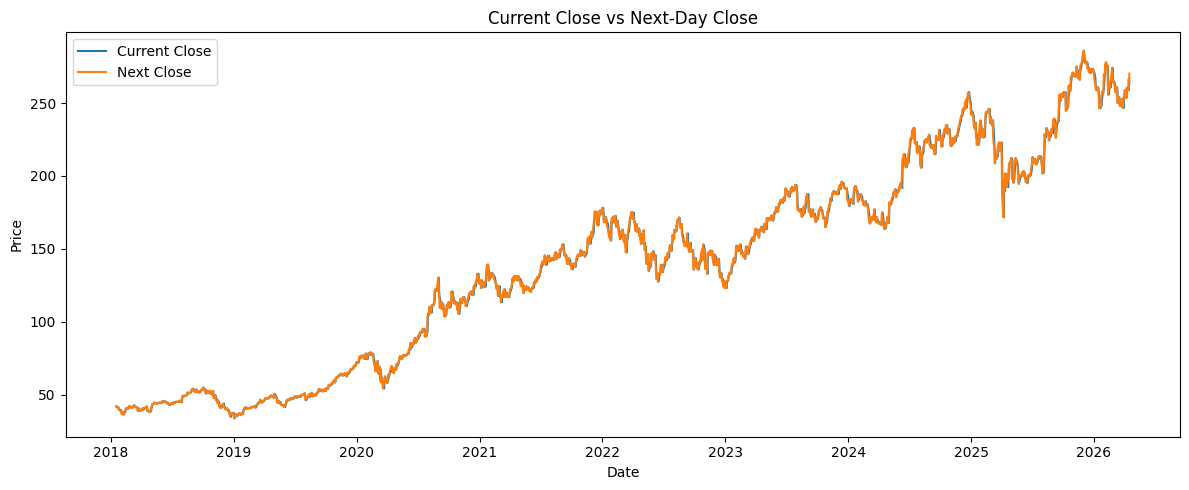

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df_model['Date'], df_model['Close'], label='Current Close')
plt.plot(df_model['Date'], df_model['next_close'], label='Next Close')
plt.title('Current Close vs Next-Day Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


## Observations

- Stock prices show strong time dependency and changing market regimes.
- Return-based targets are generally more stable than predicting raw future prices directly.
- Lag, rolling, momentum, and intraday range features help summarize short-term market behavior.
- The final training pipeline uses these engineered features to predict next-day return, then converts predictions back into next-day closing price estimates.
